# Exercise Solutions

----
## Initial Setup & Imports

In [1]:
%%capture
%matplotlib inline
!pip install uxsim matplotlib gymnasium scipy torch;

In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

import gymnasium as gym
import math
import random
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count
from scipy.optimize import minimize
from IPython.display import clear_output

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from uxsim import *
import random
import itertools
import copy

global log_rewards
global log_states
global log_epi_average_delay

/Users/calluume/miniconda3/envs/sumo-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


----
## Defining the Scenario

Choose a demand profile to test your model on. To change either the demand profile, length of each episode or control interval, update the variables below and rerun the cell.

Available profiles are:
  - `"default"`: Base scenario with some congestion and fairly even demand across all links.
  - `"heavy_demand"`: More heavily congested variant of the base scenario.
  - `"unbalanced"`: A scenario with high demand from the west of the network. The demand from all other directions is the same.
  - `"random"`: Use entirely random demand from all directions. Re-run the cell to regenerate demand. The same OD demand generated below is used throughout the rest of the notebook in training/evaluation.

In [3]:
demand_profile = "default"
scenario_len, control_interval = 3600, 10 # seconds

match demand_profile:
    case "default":
                    #  N    E    S    w
        od_demand = [[ 0,  400, 500, 400], # N
                     [400,  0,  400, 550], # E
                     [500, 400,  0,  400], # S
                     [400, 550, 400,  0 ]] # W

    case "heavy_demand":
                    #  N    E    S    w
        od_demand = [[ 0,  450, 550, 550], # N
                     [450,  0,  450, 600], # E
                     [550, 450,  0,  450], # S
                     [450, 600, 450,  0 ]] # W

    case "unbalanced":
                    #  N    E    S    w
        od_demand = [[  0, 400, 400, 400], # N
                     [400,   0, 400, 400], # E
                     [400, 400,   0, 400], # S
                     [550, 550, 550,   0]] # W

    case "random":
        od_demand = [[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]]
        for i in range(4):
            for j in range(4):
                if i == j: od_demand[i][j] = 0
                else: od_demand[i][j] = random.randint(200, 700)

    case _: raise(ValueError, "Unknown demand_profile")

In [4]:
def create_world(seed=None):
    W = World(
        name="",
        deltan=5,
        tmax=scenario_len,
        print_mode=0, save_mode=0, show_mode=1,
        random_seed=seed,
        duo_update_time=600
    )
    random.seed(seed)

    # Network definition
    tl = W.addNode("tl", 0, 0, signal=[60,60,60,60])
    north = W.addNode("north", 0, 1)
    east = W.addNode("east", 1, 0)
    south = W.addNode("south", 0, -1)
    west = W.addNode("west", -1, 0)
    all_links, origins = {}, [north, east, south, west]

    for link_idx, (org, dest) in enumerate([(north, tl), (east, tl), (south, tl), (west, tl)]):
        if org.name not in all_links: all_links[org.name] = {}
        if dest.name not in all_links: all_links[dest.name] = {}

        all_links[org.name][dest.name] = W.addLink(f"{org.name}_{dest.name}", org, dest, length=500, free_flow_speed=10, jam_density=0.2, signal_group=link_idx)
        all_links[dest.name][org.name] = W.addLink(f"{dest.name}_{org.name}", dest, org, length=500, free_flow_speed=10, jam_density=0.2, signal_group=link_idx)

    # Add demand
    for origin, demand_vals in zip(origins, od_demand):
        for idx, demand in enumerate(demand_vals):
            if demand == 0: continue
            for t in range(0, scenario_len, 30):
                W.adddemand(origin, origins[idx], t, t+30, random.uniform(0, demand*2/3600))

    return W, tl, all_links

----
## Defining the RL Agent

In [ ]:
class TrafficSim(gym.Env):
    def __init__(self):

        # Define 4 continuous state variables
        self.n_state = 4
        low = np.array([0 for i in range(self.n_state)])
        high = np.array([100 for i in range(self.n_state)])
        self.observation_space = gym.spaces.Box(low=low, high=high)

        # Define 4 discrete actions
        self.n_action = 4
        self.action_space = gym.spaces.Discrete(self.n_action)

        self.reset()

    def reset(self, seed=None):
        """
        reset the env
        """

        # Create new scenario for the current episode
        self.W, self.tl, self.all_links = create_world(seed)
        self.INLINKS = list(self.tl.inlinks.values())

        # Get initial observation
        observation = np.array([0 for i in range(self.n_state)])

        # Reset state/reward logs
        self.log_state = []
        self.log_reward = []

        return observation, None

    def comp_state(self):
        """
        Compute the current state
        """
        vehicles_per_links = {}
        for l in self.INLINKS:
            vehicles_per_links[l] = l.num_vehicles_queue #l.num_vehicles_queue = the number of vehicles queuing in link l
        return list(vehicles_per_links.values())

    def comp_n_veh_queue(self):
        return sum(self.comp_state())

    def comp_reward(self):
        raise NotImplementedError("Implement your reward function in the cell below!")

    def step(self, action_index):
        """
        Complete the next cycle of the training loop
        """

        # Decode action and update lights
        binstr = f"{action_index:04b}"
        self.tl.signal_phase = int(action_index)
        self.tl.signal_t = 0

        # Execute simulation for `control_interval` seconds
        if self.W.check_simulation_ongoing():
            self.W.exec_simulation(duration_t=control_interval)

        # Observe the environment state
        observation = np.array(self.comp_state())

        # Compute agent reward (using below function!)
        reward = self.comp_reward()

        # Check if simulation is ending early
        done = False
        if self.W.check_simulation_ongoing() == False:
            done = True

        # Log state & rewards
        self.log_state.append(observation)
        log_rewards[-1].append(reward)

        return observation, reward, done, {}, None


----
## Reward Design Solutions

As a reminder, here is the state and action setup for the DQN controller:

  - **State:** The agent has 4 continuous state variables, which are the number of vehicles queuing on each link entering the intersection.
  - **Action:** There are 4 possible actions for the agent, which represent giving green time to each link.

Therefore, during training, the model will aim to learn a policy for deciding which direction receives a green light based on the number of vehicles queuing on each incoming link. This is policy is guided by the reward function, which is always maximised by the model. Below are 4 different approaches to the design of the reward function.

Example 1 aims to train the model to maximise the average speed on all links leaving the network. Examples 2 and 3 aim to maximise the total flow and optimise density on these same links. Here, optimising density means minimising the difference between the measured density on a link and its jam density, referring to the point at which traffic is completely stopped due to congestion. Example 4 aims to minimise the number of vehicles queueing at each incoming link. The overall results of these approaches are shown below, alongside the no control results, our baseline where the traffic light is deactivated. 

|   | **Reward Function**   | **Average Speed (km/h)** | **Average Delay (s)** | **Total Distance Travelled (m x 10^6)** | **Total Travel Time (vehicle hours)** |
|---|-----------------------|--------------------------|-----------------------|-----------------------------------------|---------------------------------------|
| - | No Control            | 15.8                     | 126.3                 | 2.12                                    | 131.1                                 |
| 1 | `maximise_speed()`    | 15.1                     | 132.3                 | 1.99                                    | 125.8                                 |
| 2 | `maximise_outflow()`  | 19.1                     | 92.6                  | 1.98                                    | 105.4                                 |
| 3 | `optimise_density()`  | 23.0                     | 59.5                  | 2.12                                    | 94.6                                  |
| 4 | `minimise_queueing()` | 24.1                     | 50.6                  | 2.02                                    | 85.4                                  |

Whilst each approaches produces different results, none are inherently bad as they all are aiming for the same goal of reduced congestion. However, some have subtle drawbacks:

  1. **Maximising Speed**: This can be beneficial as higher speeds of outgoing vehicles can often be a result of higher vehicle throughput, with more vehicles able to pass the intersection without slowing down. Yet, higher average speeds could also be due to fewer vehicles being served, so the controller may favour approaches with low demand instead of efficiently serving vehicles.
  2. **Maximising Outflow**: More directly related to vehicle throughput than maximising speed, but only considers vehicles leaving the network. The reward is quite localised, with no direct penalty from vehicle queues growing longer. There is also a delay in the reward, as vehicles need time between receiving a green light and when they leave the network, meaning there is a weaker learning signal from the model.
  3. **Optimising Density**: Optimising density is a common goal of many traffic control systems, as maintaining density close to the jam (or critical) density ensures we are making the most efficient use of available road capacity. Yet, the reward is localised again, with no penalty for congestion on the links entering the intersection.
  4. **Minimise Queueing**: This reward function produced the best overall results, with a very fast convergence during training. In this case, any vehicle waiting on any of the incoming links immediately contributes to the reward, and the reward is improved as soon as the vehicle passes through the intersection. This produces a strong and consistent learning signal for the model, with very positive final results. Other designs focusing on the incoming links can also produce good results, such as minimising the number of vehicles or even density.

Ultimately, whilst the reward function should balance long term performance and immediate reward, it still must reflect what the controller can influence. Reinforcement learning models learn through trial-and-error, repeatedly carrying out an action, observing the environment state and trying again, encoding the knowledge from each experience in its policy. Yet, in order to learn and encode these experiences, the reward must be closely linked to the state and action and the model must be able to quickly influence the reward through its possible actions. Any delayed or inconsistent reward can prevent the model from learning to relate states and positive actions.

In this case, whilst measures such as throughput may appear to be a good reward, this hides relevant information from the model and does not produce as clear of a reward signal. By considering the problem more directly as a model learning how to 'serve' each of the 4 incoming links with a green light, we can explicitly guide the model by telling it to reduce the number of vehicles waiting on each link. This is very directly linked to both the model's immediate state and the consequences of its actions, whilst having a strong correlation with our overall long term goal.

You can continue to work on your own reward function, or modify and run the examples below!

In [ ]:
origin_nodes = ['north', 'east', 'south', 'west']

def maximise_speed(self):
    """ Example 1: Maximise the average speed on outgoing links. """

    return sum([self.all_links[origin]['tl'].speed for origin in origin_nodes]) / 4

def maximise_outflow(self):
    """ Example 2: Maximise the total outflow of the network. """

    return sum([self.all_links['tl'][origin].flow for origin in origin_nodes])

def optimise_density(self):
    """ Example 3: Optimise density on outward links, minimising the difference between current density and jam density. """

    reward = 0
    for origin in origin_nodes:
        link = self.all_links['tl'][origin]
        reward -= abs(link.density - link.jam_density) / link.jam_density

    return reward

def minimise_queueing(self):
    """ Example 4: Minimise the number of vehicles queuing at links entering the traffic light. """

    return -sum([self.all_links[origin]['tl'].num_vehicles_queue for origin in origin_nodes])

# Do not delete
TrafficSim.comp_reward = minimise_queueing

### Defining the Deep Q-Network

For more information on DQNs:

1. V. Mnih, K. Kavukcuoglu, D. Silver, A. Graves, I. Antonoglou, D. Wierstra, and M. A.
Riedmiller, “[_Playing Atari with Deep Reinforcement Learning_](https://arxiv.org/pdf/1312.05602),” 2013. arXiv: 1312.5602.
2. Y. Huang, “[_Deep Q-Networks_](https://link.springer.com/chapter/10.1007/978-981-15-4095-0_4),” in Deep Reinforcement Learning: Fundamentals, Research
and Applications (H. Dong, Z. Ding, and S. Zhang, eds.), pp. 135–160, Springer
Singapore, 2020.

In [131]:
env = TrafficSim()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))

class ReplayMemory(object):
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

class DQN(nn.Module):
    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        n_neurals = 64
        n_layers = 3
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(n_observations, n_neurals))
        for i in range(n_layers):
            self.layers.append(nn.Linear(n_neurals, n_neurals))
        self.layer_last = nn.Linear(n_neurals, n_actions)

    # Called with either one element to determine next action, or a batch during optimization. Returns tensor([[left0exp,right0exp]...]).
    def forward(self, x):
        for layer in self.layers:
            x = F.relu(layer(x))
        return self.layer_last(x)

def select_action(state):
    global steps_done
    sample = random.random()
    eps_threshold = EPS_END + (EPS_START - EPS_END) * math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1
    if sample > eps_threshold:
        with torch.no_grad():
            # t.max(1) will return the largest column value of each row. second column on max result is index of where max element was found, so we pick action with the larger expected reward.
            return policy_net(state).max(1)[1].view(1, 1)
    else:
        return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)

def optimize_model():
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)
    # Transpose the batch (see https://stackoverflow.com/a/19343/3343043 for detailed explanation). This converts batch-array of Transitions to Transition of batch-arrays.
    batch = Transition(*zip(*transitions))

    # Compute a mask of non-final states and concatenate the batch elements (a final state would've been the one after which simulation ended)
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state
                                                if s is not None])
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    # Compute Q(s_t, a) - the model computes Q(s_t), then we select the columns of actions taken. These are the actions which would've been taken for each batch state according to policy_net
    state_action_values = policy_net(state_batch).gather(1, action_batch)

    # Compute V(s_{t+1}) for all next states.
    # Expected values of actions for non_final_next_states are computed based on the "older" target_net; selecting their best reward with max(1)[0].
    # This is merged based on the mask, such that we'll have either the expected state value or 0 in case the state was final.
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1)[0]
    # Compute the expected Q values
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # Compute Huber loss
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    # Optimize the model
    optimizer.zero_grad()
    loss.backward()
    # In-place gradient clipping
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

# (hyper)parameters

# The number of transitions sampled from the replay buffer
BATCH_SIZE = 128
# The discount factor
GAMMA = 0.99
# The starting value of epsilon
EPS_START = 0.9
# The final value of epsilon
EPS_END = 0.05
# The rate of exponential decay of epsilon, higher means a slower decay
EPS_DECAY = 1000
# The update rate of the target network
TAU = 0.005
# The learning rate of the ``AdamW`` optimizer
LR = 1e-4

# Get number of actions from gym action space
n_actions = env.action_space.n
# Get the number of state observations
state, info = env.reset()
n_observations = len(state)

policy_net = DQN(n_observations, n_actions).to(device)
target_net = DQN(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayMemory(10000)

### Perform Training Loop

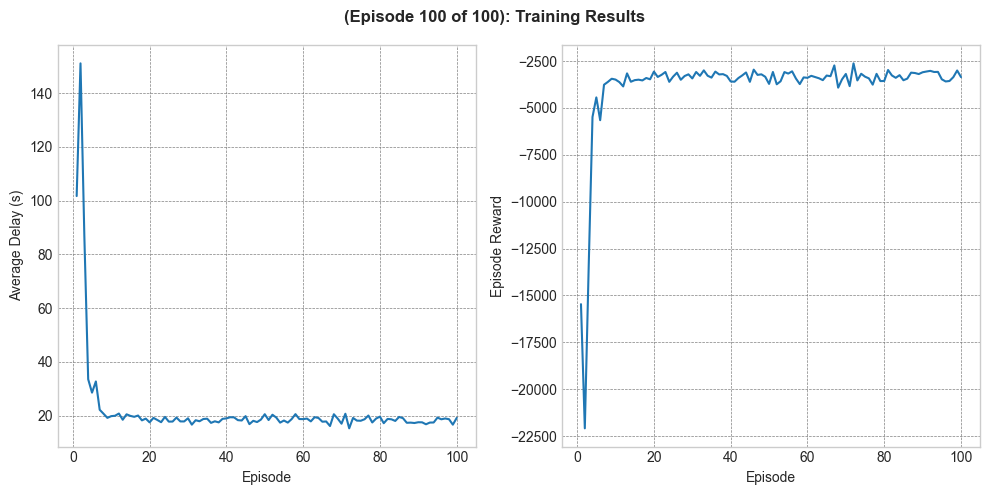

In [132]:
log_rewards, log_states = [], []
log_epi_average_delay = []

steps_done = 0
num_episodes = 100

for i_episode in range(num_episodes):
    # Initialise the environment and get the initial state
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    log_rewards.append([])
    log_states.append([])
    for t in count():
        action = select_action(state)
        observation, reward, terminated, truncated, _ = env.step(action.item())
        reward = torch.tensor([reward], device=device)
        done = terminated or truncated

        if terminated:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

        log_states[-1].append(state)

        # Store the transition in memory
        memory.push(state, action, next_state, reward)

        # Move to the next state
        state = next_state

        # Perform one step of the optimization (on the policy network)
        optimize_model()

        # Soft update of the target network's weights
        # θ′ ← τ θ + (1 −τ )θ′
        target_net_state_dict = target_net.state_dict()
        policy_net_state_dict = policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
        target_net.load_state_dict(target_net_state_dict)

        if done:
            log_epi_average_delay.append(env.W.analyzer.average_delay)
            break

    # Visualise Training
    clear_output(wait=True)
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, (d_ax, r_ax) = plt.subplots(1, 2, figsize=(10, 5))
    d_ax.plot(range(1, len(log_epi_average_delay) + 1), log_epi_average_delay)
    d_ax.set_ylabel("Average Delay (s)")
    r_ax.plot(range(1, len(log_rewards) + 1), [sum(ep_data) for ep_data in log_rewards])
    r_ax.set_ylabel("Episode Reward")
    for ax in (d_ax, r_ax):
        ax.set_xlabel("Episode")
        ax.grid(True, 'both', color='grey', linestyle='dashed', linewidth=0.5)
    fig.suptitle(f"(Episode {i_episode+1} of {num_episodes}): Training Results", fontweight="bold")
    fig.tight_layout()
    plt.show()


----
## Run Final Evaluation

In [133]:
steps_done, seed = 0, 1
g_times = [0, 0, 0, 0]

state, info = env.reset()
state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
for t in count():
    action = select_action(state)
    observation, reward, terminated, truncated, _ = env.step(action.item())
    done = terminated or truncated

    g_times[action.item()] += control_interval

    if terminated: next_state = None
    else: next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)
    state = next_state

    if done: break

env.W.analyzer.print_simple_stats(force_print=True)

results:
 average speed:	 6.9 m/s
 number of completed trips:	 2175 / 2315
 total travel time:		 318700.0 s
 average travel time of trips:	 146.5 s
 average delay of trips:	 46.5 s
 delay ratio:			 0.318
 total distance traveled:	 2186500.0 m


----
## Visualise Results

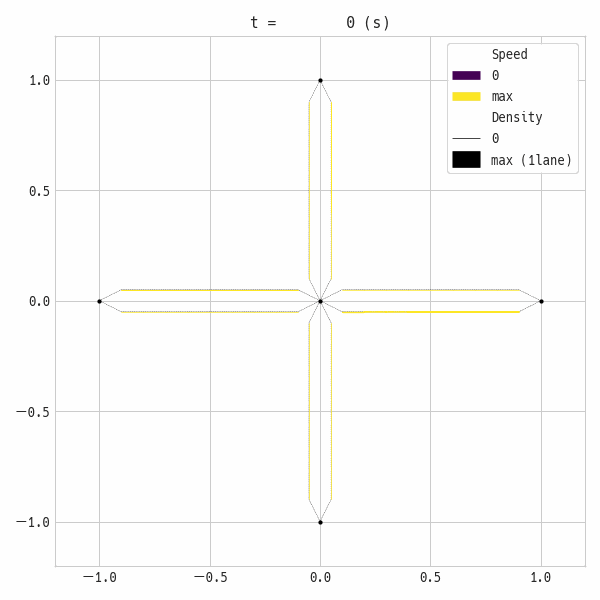

In [134]:
gif_loc = "final_eval.gif"
env.W.analyzer.network_anim(detailed=1, figsize=(6,6), network_font_size=0, file_name=gif_loc)

from IPython.display import display, Image
with open(gif_loc, "rb") as f: display(Image(data=f.read(), format='png'))

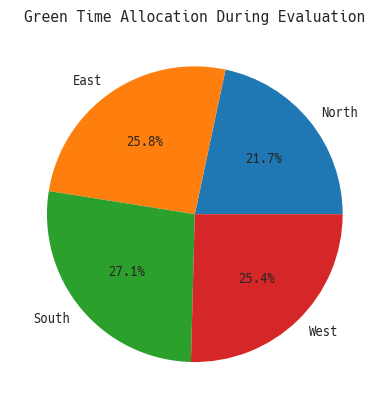

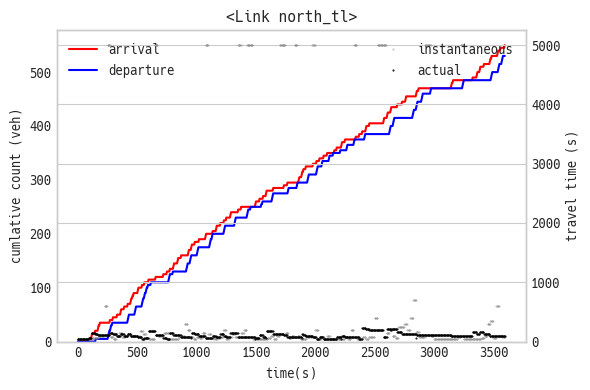

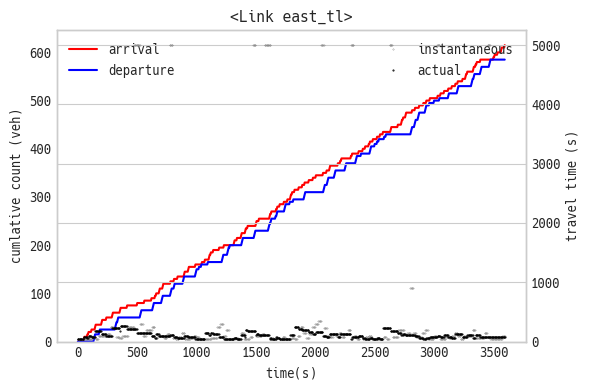

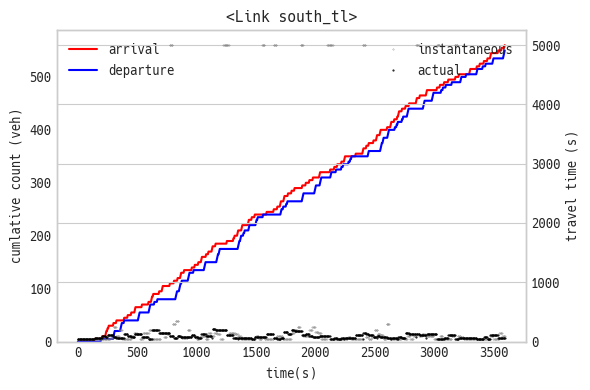

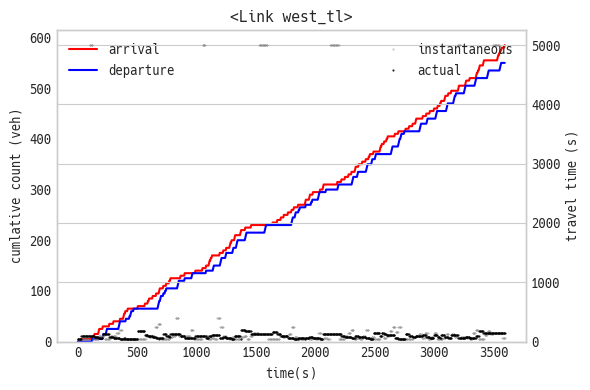

In [135]:
nodes = ['north', 'east', 'south', 'west']

fig, ax = plt.subplots()
ax.pie(g_times, labels=[n.title() for n in nodes], autopct='%1.1f%%')
ax.set_title("Green Time Allocation During Evaluation")

env.W.analyzer.cumulative_curves([f"{org}_tl" for org in nodes])